## Séminaire 3. Transformées de Radon dans diverses tomographies

In [60]:
import os # work with filesystem

import numpy as np
import tomopy as tp # standard reconstruction algorithms
import matplotlib.pyplot as plt

import odl         # operator discretization library

import wget        # library for URL-downloads
import dxchange    # library fpr opening DX-files (tomographic format)
import numba as nb # LLVM acceleration library

import warnings    # supress ugly warnings
warnings.filterwarnings('ignore')

$\def\label#1{}$
$\def\ref#1{\text{ref}}$

### Table des matières

<p><div class="lev1"><a href="#1.-Introduction"><span class="toc-item-num"></span>1. Introduction</a></div>
<p><div class="lev1"><a href="#2.-Tomographie-radiologique-avec-données-complètes.-Modèle-statistique"><span class="toc-item-num"></span>2. Tomographie radiologique avec données complètes. Modèle statistique</a></div>
<p><div class="lev1"><a href="#3.-Tomographies-émissonnelles-PET-/-SPECT"><span class="toc-item-num"></span>3. Tomographies émissonnelles PET / SPECT</a></div>
<p><div class="lev1"><a href="#4.-Microtomographie-(MicroCT)"><span class="toc-item-num"></span>4. Microtomographie (MicroCT)</a></div>

**Important :** pour ce séminaire, vous aurez besoin de votre numéro individuel, qui vous sera distribué par le conférencier au début du séminaire.

In [1]:
# set id (will be used later to download binary data)
my_id = 0

## 1. Introduction

### 1.1 Tomographies et transformations de Radon

Les transformations de Radon et les transformations de Radon pondérées apparaissent dans diverses tomographies. 
Voici quelques exemples :

 * tomodensitométrie par rayons X 

 * tomographies émissives (SPECT / PET / tomographie de fluorescence)

 * tomographie optique modulée par ultrasons (UMOT - ultrasound modulated optical tomography)
 
 * microtomographie (tomographie d'objets petits avec une très haute résolution)

Il existe d'autres exemples, par exemple dans l'IRM (imagerie par résonance magnétique), 
le problème inverse peut également être formulé comme un problème inverse 
pour la transformation de Radon, mais dans ce travail, nous examinerons les exemples les plus classiques.

### 1.2 Problèmes avec les transformations de Radon en pratique

<table>
<tr>
 <td> <img src="./noisy-sinogram.png" alt="noisy-sim" style="width: 400px; height: 250px"/> </td>
 <td> <img src="./noise-free-sinogram.png" alt="noise-free-sim" style="width: 400px; height: 250px"/> </td>
    <td> <img src="./photon-matter-interaction.png" alt="photon-matter" style="width: 200px; height: 250px"/> </td>
</tr>
<tr>
 <td> <center> exemple de données réelles en TDM avec du bruit </center> </td>
 <td> <center> données "virtuelles" de TDM sans bruit </center> </td>
 <td> <center> types d'interaction des photons et de la matière en TDM à rayons X (voir les cours) </center> </td>
</tr> 
</table>

Il est évident que nous devons comprendre que les transformations de Radon sont une idéalisation mathématique de ce qui se passe dans une procédure tomographique réelle :

1. les données rayonnantes ne sont jamais connues avec précision, mais toujours avec une certaine erreur (parfois très significative)

2. les données rayonnantes ne sont connues que pour un nombre fini de rayons (le volume des données est limité par la capacité de mémoire de l'ordinateur et également par les protocoles médicaux interdisant de faire trop de mesures si l'on utilise une radiation ionisante)

3. les photons (ou autres particules) ne se propagent jamais le long de lignes idéales - ils peuvent être diffusés, atteindre d'autres détecteurs, et en outre - un faisceau de particules a une épaisseur finie dans la section (généralement quelques millimètres)

4. l'interaction entre la matière et les photons est seulement approximativement décrite par la loi de Beer-Lambert-Bouguer (un modèle plus précis est très complexe et inclut plusieurs effets : diffusion de Rayleigh et de Compton, diffusion électronique, création d'électron-positron et autres)

5. les détecteurs peuvent parfois être défectueux, introduisant ainsi une erreur systématique dans les mesures, et donc dans la reconstruction

6. enfin - les patients peuvent bouger pendant la procédure (ainsi que la respiration, le battement de cœur, qui ne sont pas annulés)

Il y a également de nombreux autres effets auxquels vous avez pu être exposés lors des cours pratiques.

Ainsi, en reconstruisant une image à partir des données rayonnantes et en supposant qu'elles sont décrites par les transformations de Radon, nous obtenons inévitablement une image avec une erreur. Cependant, l'expérience a montré que ce modèle décrit bien ce qui se passe en pratique, c'est pourquoi nous l'utilisons.

### 1.3 Artéfacts. Quelques exemples.

En raison du fait que notre modèle n'est pas parfait et parfois même trop simplifié, nous observons parfois des modifications systématiques sur les images restaurées qui ne sont pas liées à la réalité physique. Ces modifications sont appelées en pratique et dans la littérature scientifique **artéfacts**.

<table>
<tr>
 <td> <img src="./beam-hardening-2.png" alt="beam-hardening" style="width: 300px; height: 180px"/> </td>
 <td> <img src="./metal-artifact.png" alt="metal-tooth" style="width: 200px;"/> </td>
    <td> <img src="./ring-artifact.png" alt="ring-artifact" style="width: 220px; height: 220px"/> </td>
</tr>
<tr>
 <td> <center> Fig. 2. (a) durcissement du faisceau - à gauche, correction - à droite </center> </td>
 <td> <center> Fig. 2. (b) présence d'un implant métallique </center> </td>
 <td> <center> Fig. 2. (c) artéfact en anneau (capteur endommagé) </center> </td>
</tr> 
</table>

Sur les figures (a), (b) et (c) sont représentés des artéfacts qui apparaissent fréquemment dans la tomographie par rayons X. Sur la figure (a), on observe l'effet de "durcissement du faisceau" - les lignes sombres n'existent pas en réalité. Cet artéfact se produit car le modèle de restauration ne prend pas en compte le fait que le faisceau émis par la source X est *polychromatique*, et que le coefficient d'atténuation $\mu$ dépend non seulement des coordonnées, mais aussi de l'énergie des photons traversant le matériau, c'est-à-dire $\mu = \mu(x, E)$. Sur la figure (b), on voit un artéfact fort sous forme de sauts le long des lignes qui traversent l'implant métallique dans la dent. En effet, le métal diffuse fortement le faisceau incident, ce qui n'est pas décrit par le modèle mathématique sur lequel repose l'algorithme de restauration. Sur la figure (c), l'artéfact prend la forme d'un anneau centré dans l'image. Cet artéfact est un signe que l'un des détecteurs est défectueux et enregistre incorrectement le faisceau incident (ou ne l'enregistre pas du tout).

 ### 1.4 Rappel

Le transformé de Radon classique $R$ sur $R^2$ est défini par la formule suivante :
\begin{equation}\label{radon-def}
    Rf(s,\theta) = \int\limits_{-\infty}^{+\infty} f(s\theta+ t\theta^\perp) \, dt, 
    \, s\in R, \, \theta\in S^1.
\end{equation}

Le transformé de Radon pondéré $R_W$ sur $R^2$ est défini comme
\begin{equation}\label{wradon-def}
    R_Wf(s,\theta) = \int\limits_{-\infty}^{+\infty} W(s\theta + t\theta^\perp, \theta) f(s\theta+ t\theta^\perp) \, dt, 
    \, s\in R, \, \theta\in S^1,
\end{equation}
où la fonction $W=W(x,\theta), \, x\in R^2, \, \theta\in S^{1}$ est appelée **poids**.

### 1.5 Ce que nous voulons montrer dans cet exercice ?

 1. Montrer différents exemples de tomographies qui utilisent le modèle des transformés de Radon

 2. Montrer que le modèle des transformés de Radon *n'est pas parfait, mais utile* (c'est-à-dire - montrer certains rétablissements réussis et d'autres - échoués)

 3. Discuter certaines causes d'artefacts et essayer de les éliminer (si c'est possible dans le cadre du modèle des transformés de Radon)

Dans les exercices suivants, nous examinerons trois types de tomographies :

 1. la tomographie par résonance magnétique avec des données complètes

 2. la tomographie à émission mono-photone et la tomographie à émission de positrons (PET / SPECT)

 3. la microtomographie (MicroCT)

**Remarque 1 :** Dans cet exercice, notre objectif n'est pas d'utiliser les algorithmes les plus modernes et optimaux. Leur implémentation est complexe dans le cadre de ce cours, donc nous ne considérons que ceux qui garantissent une "solution", "convergence". Un excellent aperçu des algorithmes utilisés peut être trouvé dans les liens suivants [Statistical Image Reconstruction Methods, 2016](https://web.eecs.umich.edu/~fessler/book/fessler-00-sir,spie-scan.pdf), [J. Fessler website](https://web.eecs.umich.edu/~fessler/).

**Remarque 2 :** Dans vos implémentations, si des bibliothèques tierces ne sont pas utilisées, il est recommandé d'utiliser la bibliothèque **Numba** pour accélérer les calculs.

## 2. Tomographie radiologique avec des données complètes. Modèle statistique

La tomographie radiologique (tomographie par ordinateur) est une méthode de construction d'une image de la structure interne d'un objet en utilisant les rayons X comme outil d'exploration. En pratique, on utilise des photons avec des énergies comprises entre 50 et 150 keV pour que le rayonnement ait une pénétration suffisante (plus l'énergie est élevée, moins l'absorption et la diffusion sont importantes, plus la pénétration est grande, mais moins le contraste est élevé).

Comme cela a été dit lors du cours - la base du modèle mathématique de la tomographie radiologique est la *loi de Beer-Lambert-Bouguer* :

\begin{equation}
    I = I_0 e^{-\mu\cdot d}, 
\end{equation}
où $\mu$ est le coefficient d'absorption linéaire, $d$ est l'épaisseur de l'échantillon irradié. En tenant compte du fait que le coefficient $\mu$ n'est pas constant, on obtient la formule suivante :

\begin{equation}
    I(s,\theta) = I_0 e^{-R\mu(s,\theta)}, (s,\theta)\in R\times S^1, (s,\theta) \text{ - rayon dans le plan }R^2,
\end{equation}

où $R\mu$ est la transformation de Radon de la carte d'absorption $\mu = \mu(x)$, $x\in R^2$. 

Ainsi, la valeur de la transformation de Radon peut être trouvée par la formule :

\begin{equation}
    R\mu(s,\theta) = \log\left( \dfrac{I_0}{I(s,\theta)} \right), 
\end{equation}
où $I(s,\theta)$ est l'intensité mesurée le long du rayon $(s,\theta)$.

**Modèle statistique des données :** l'intensité du rayonnement est mesurée en J / $c\cdot \text{m}^2$, c'est-à-dire que c'est l'énergie passant à travers une surface unitaire par seconde. Dans le modèle le plus simple, le détecteur enregistre simplement les photons arrivant, autrement dit il les **compte** (pour plus de détails sur le modèle d'enregistrement des photons, voir [ici](https://web.eecs.umich.edu/~fessler/course/516/l/c6-noise.pdf)).

L'énergie passant à travers la surface du détecteur par unité de temps est $E = h\nu \cdot N$, où $N$ est le nombre de photons arrivant. Si on considère que initialement $N_0$ photons ont quitté le "canon", alors pour les données de rayonnement, on obtient la formule suivante (toutes les autres constantes se simplifient) :

\begin{equation}
    R\mu(s,\theta) = \log\left( \dfrac{N_0}{N} \right).
\end{equation}

En réalité, les valeurs $N_0, N$ ne sont pas constantes - techniquement, il est impossible (et inutile) de contrôler chaque départ d'un photon du canon et chaque impact sur l'écran. Les valeurs $N, N_0$ sont aléatoires et ont une distribution proche de la distribution de Poisson :

\begin{align}
    N_0 &\sim \mathrm{Po}(\Lambda \cdot t), \\
    N(s,\theta) | N_0 &\sim  \mathrm{Binomial}(N_0, e^{-R\mu(s,\theta)}), 
\end{align}

où $\Lambda$ est la puissance de l'émetteur (nombre de photons générés / seconde), $t$ est le temps d'émission.

Ainsi, sur chaque photon émis, un expérience de Bernoulli est réalisée : avec une probabilité $e^{-Ra(s,\theta)}$, le photon partira à l'infini, avec une probabilité $1-e^{-Ra(s,\theta)}$, il sera absorbé par le milieu.

Ce processus est appelé **flux de Poisson avec dilution**. Il n'est pas difficile de montrer que finalement la valeur $N(s,\theta)$ aura également une distribution de Poisson, mais avec un autre paramètre :

\begin{align}
    N(s,\theta) \sim \mathrm{Po}(\Lambda e^{-R\mu(s,\theta)} \cdot t).
\end{align}

Alors, pour "estimer" la valeur $R\mu(s,\theta)$, on utilise l'estimation suivante :

\begin{equation}
    \widehat{Ra}(s,\theta) = \log\left(
        \dfrac{\Lambda}{N(s,\theta)}
    \right),
\end{equation}

en supposant que $\Lambda$, $t$ sont connus (ils peuvent être déterminés à partir des conditions de l'expérience et de la calibration du générateur de particules).

#### Algorithme naïf de reconstruction

En se basant sur tout ce qui a été dit, on peut immédiatement proposer l'algorithme de reconstruction suivant :

     # Algorithm 1 for reconstruction from photon counts in X-ray tomography
     
     # BEGIN
     
        1. Input : Lambda, N(s, theta)
        2. Compute : R[mu](s, theta) = log( Lambda / N(s, theta))
        3. Apply Filtered Backprojection Algorithm to get mu(x) from R[mu](s,theta).
     
     # END

**Exercice 2.1** Appliquez cet algorithme aux données de rayons $N(s,\theta)$. Supposons que le temps d'acquisition pour chaque rayon était $t=1c$, et que l'intensité de la source est $\Lambda = 10^5c^{-1}$. Le format des données est indiqué ci-dessous. En tant qu'algorithme de projection inverse, vous pouvez utiliser votre algorithme du premier séminaire ou tout algorithme standard FBP de la bibliothèque `skimage.transform`, `tomopy`, `astra-toolbox` (il est important qu'il fonctionne correctement). Évaluez visuellement la reconstruction, voyez-vous des distorsions artificielles sur l'image ? Essayez d'expliquer leur cause si elles existent.

    format des données : fichier binaire 
        ntheta = 512 
        ns=512 
        grille : uniforme 
    flottants de 4 octets chacun, format binaire - little endian

In [ ]:
# code to download binary with photon counts

fname_high_intensity = 'strong-int-proj-covid-data_' + str(my_id) + '.bin'
url_prefix = 'https://raw.github.com/fedor-goncharov/' + \
          'pdo-tomography-course/master/seminar-materials/seminar-3/covid-counts-high-intensity/'
url = url_prefix + fname_high_intensity
wget.download(url)

In [ ]:
# YOUR CODE HERE

**Réponse à l'exercice 2.1:** VOTRE RÉPONSE ICI

### 2.1. Algorithme naïf de reconstruction avec une faible dose d'irradiation

Dans l'exercice précédent la valeur de l'intensité était suffisamment grande $\Lambda=10^5s^{-1}$ et les reconstructions étaient assez satisfaisantes. Il est important ici de rappeler que dans le contexte tomographique médical il n'est pas possible d’irradier trop fortement un objet.

Dans certains cas la dose d'irradiation doit être minimale par exemple si le patient va subir des autres procédures diagnostiques liées à l'ionisation (par exemple des examens PET/SPECT ou radiothérapie). Dans ce scénario soit on réduit l'émission initiale $\Lambda$ ou bien on diminue le temps d’exposition $t$, mais c’est important qu **le modèle statistique reste identique** (c.-à-d., les données suivent encore une distribution de Poisson).

**Question (optionnelle):** Comment changerait-on la qualité des reconstructions en diminuant substantiellement le paramètre $\Lambda$ ou $t$ ? Essayez de répondre analytiquement (examinez la fonction vraisemblance et voyez comment sa convexité change avec le temps t).

**Exercice 2.2:** Appliquez l'algorithme FBP aux données rayonnantes $N(s,\theta)$ chargées via le code ci-dessous. Supposons que chaque faisceau a été exposé pendant un temps $t=0,1s$, et que son intensité était égale à 
$\Lambda =5\cdot10^3 s^{-1}$. Vous pouvez utiliser votre algorithme de projection inverse du premier séminaire, ou n’importe quel algorithme standard FBP provenant des bibliothèques `skimage.transform`, `tomopy` ,ou `astra-toolbox`. Quelle est la différence dans la qualité de reconstruction par rapport à l'exercice précédent? Pouvez-vous expliquer vos résultats et leurs raisons associées?

In [67]:
# download binary with photon counts

fname_weak_intensity = 'weak-int-proj-covid-data_' + str(my_id) + '.bin'
data_status = os.path.exists('./' + fname_weak_intensity)

if data_status == "False":
    url_prefix = 'https://raw.github.com/fedor-goncharov/' + \
        'pdo-tomography-course/master/seminar-materials/seminar-3/covid-counts-low-intensity/'
    url = url_prefix + fname_weak_intensity
    wget.download(url)

In [ ]:
sinogram_data = np.reshape(np.fromfile(fname_weak_intensity, dtype=np.float), (512, 512))

# YOUR CODE HERE

**Réponse à l'exercice 2.2 :** VOTRE RÉPONSE ICI

### 2.2. Rapport signal-bruit (SNR - signal-to-noise ratio)

**Où avons-nous menti dans notre modèle ?** Comme on peut le voir dans les exemples ci-dessus, les reconstructions sont sensibles au nombre de photons enregistrés (plus il y en a, mieux c'est). On peut remarquer que dans le modèle de la transformation de Radon pure, la nature statistique des données de rayonnement n'est pas prise en compte. Comme on peut le voir dans les exemples précédents, cela est d'une importance significative dans les cas où la dose d'irradiation doit être minimale.

**Quel est le problème ? Pourquoi les reconstructions sont-elles bonnes lorsque $\Lambda$ est grand et mauvaises lorsque $\Lambda$ est petit ?**
Le problème est que les données de rayonnement ont une *distribution de Poisson*, qui possède les propriétés suivantes :

\begin{equation}
    \xi \sim \mathrm{Po}(\lambda), \, \mathbb{E}\xi = \lambda, \, \mathrm{Var}\xi = \lambda.
\end{equation}

Du point de vue pratique, nous reconstruisons des images à partir des signaux enregistrés par le détecteur, qui correspondent à l'intensité des photons arrivant. Une caractéristique importante de la qualité du signal est la quantité appelée *rapport signal-bruit (SNR - signal to noise ratio)* :

\begin{equation}
    \mathrm{SNR} = \dfrac{\overline{\Delta I} }{\sigma_I}.
\end{equation}
La quantité $\Delta I = |I-I_b|$ représente la différence absolue entre le signal d'intérêt et le signal provenant du fond, $\sigma_I$. Alors, en termes de tomographie par rayons X, nous avons $I_b = \Lambda_0$, $I = \Lambda_0e^{-R\mu}$, $\sigma_I = \sqrt{\mathrm{Var}(\xi_0)} = \sqrt{\Lambda_0}$.

La quantité SNR peut être écrite de la manière suivante :
\begin{equation}
    \text{SNR} = \dfrac{\overline{\Delta I}}{\sigma_I} = \dfrac{\overline{\Delta I}}{I_b} \cdot \dfrac{I_b}{\sigma_I}
    = C \sqrt{\Lambda_0}, \, C = \dfrac{\overline{\Delta I}}{I_b}.
\end{equation}

Dans la formule ci-dessus, la quantité $C$ est appelée *contraste relatif*. Ainsi, on peut dire que la quantité SNR est proportionnelle au contraste et à la racine carrée de l'intensité du rayonnement initial. Plus le SNR est faible, plus le signal est bruité et plus les reconstructions sont mauvaises. Cela peut être illustré par l'exemple numérique suivant.

<table>
<tr>
 <td> <img src="./scheme_contrasts.png" alt="contrasts" style="width: 400px; height: 300px"/> </td>
 <td> <img src="./snr_scheme_contrasts.png" alt="snr" style="width: 400px;height: 300px"/> </td>
 <td> <img src="./snr_contrasts.png" alt="noise" style="width: 400px; height: 300px"/> </td>
</tr>
<tr>
 <td> <center> Fig. 3. (a) graphe des contrastes </center> </td>
 <td> <center> Fig. 3. (b) graphe des valeurs SNR </center> </td>
 <td> <center> Fig. 3. (c) réalisation du signal avec un bruit de Poisson </center> </td>
</tr> 
</table>

*Le critère empirique de [Rouzaud](https://en.wikipedia.org/wiki/Signal-to-noise_ratio)* stipule que "lorsque SNR < 0.5, l'œil humain ne peut pas distinguer le signal du fond avec une précision de 100%".


Dans notre cas, lorsque $\Lambda_0$ est petit, le SNR est également petit. Nous savons aussi des séminaires précédents que l'inversion de la transformation de Radon est numériquement instable, ce qui se manifeste par un bruit élevé ou un faible SNR.

**Comment peut-on améliorer les reconstructions même en présence d'un fort bruit (temps d'observation faible) ?** Pour cela, il faut tenir compte des propriétés statistiques des données de rayonnement. Nous proposons **deux** approches pour résoudre ce problème :

1. Utiliser la régularisation de Tikhonov avec une régularisation quadratique.
2. Utiliser l'estimation du maximum de vraisemblance (maximum likelihood estimate) pour un modèle généralisé de Poisson.

En pratique, on utilise souvent la deuxième solution avec une régularisation spécifique [(voir par exemple J. Fesseler)](https://www.spiedigitallibrary.org/ebooks/PM/Handbook-of-Medical-Imaging-Volume-2-Medical-Image-Processing-and/1/Statistical-Image-Reconstruction-Methods-for-Transmission-Tomography/10.1117/3.831079.ch1). Dans le contexte de l'utilisation de méthodes itératives matricielles, il y a toujours un problème de "grands ensembles de données" (en dimension 3), que nous ne traitons pas ici.

**Exercice 2.3** (restauration par régularisation de Tikhonov) Dans ce cas, l'image que nous voulons obtenir est la solution du problème d'optimisation suivant :
\begin{equation}
    \widehat{\mu}_\gamma = \arg\min_\mu \|A\mu - g\|^2 + \gamma \|\mu\|^2, \gamma > 0, \, g = \widehat{P\mu(s,\theta)}
\end{equation}
où $\gamma$ est le paramètre de régularisation et $\widehat{P\mu}$ sont les données rayonnantes connues. Le fonctionnel ci-dessus peut être différencié par rapport à $\mu$ et égalé à zéro. La solution du problème d'optimisation mentionné précédemment se réduit alors à la résolution de l'équation suivante :

\begin{equation}
    (A^*A + \gamma I )\mu = A^* g, \, g = \widehat{P\mu}.
\end{equation}

Le code ci-dessous utilise la bibliothèque [ODL (Operator Discretization Library)](https://odlgroup.github.io/odl/) pour résoudre cette équation. Le choix optimal du paramètre de régularisation $\gamma$ est l'objet de nombreuses discussions. Dans cet exercice, vous êtes invité à trouver la valeur optimale de $\gamma$ en évaluant les restaurations visuellement et en les comparant à l'image de l'exercice 2.1. (formellement, on peut utiliser un certain critère numérique, par exemple, la distance $L^2$ minimale entre l'image restaurée et l'image originale ; en réalité, une telle comparaison est impossible)

In [ ]:
# construction of the optimization problem

# create reconstruction space: discretized functions on rectangle 
# [-1,1]^2 with 512 samples per dimension
recon_space = odl.uniform_discr(
                min_pt = [-1., -1.], max_pt = [1., 1.], shape=[512, 512], dtype='float32')

# create angle partition: uniform angles from (0, 2pi), 512 angles
angle_partition = odl.uniform_partition(0, 2.0*np.pi, 512)

# create detectors partition: in each projection 512 detectors
detector_partition = odl.uniform_partition(-1., 1., 512)
geometry = odl.tomo.Parallel2dGeometry(angle_partition, detector_partition)

# create forward operator (matrix for the Radon transform)
ray_operator = odl.tomo.RayTransform(recon_space, geometry)

# prepapare the solver for the optimization problem
penalty = odl.IdentityOperator(recon_space)

# rule of thumb for choice of l2-regularization penalty
gamma = 1.1

# operator on the left hand-side
T = ray_operator.adjoint * ray_operator + gamma * penalty.adjoint * penalty
# known part in the right hand-side
b = ray_operator.adjoint(projection_data.transpose())


In [ ]:
# find optimal value for the regularization parameter

mu = recon_space.zero()

# 15 iterations of the conjugate gradient descent / print the result
odl.solvers.conjugate_gradient(T, mu, b, niter = 15)
mu.show();

# YOUR CODE HERE


**Question pour l'exercice 2.3.** La reconstruction s'est améliorée, mais nous n'avons pas du tout utilisé le modèle statistique des données (c.-à-d. la distribution de Poisson). Pouvez-vous expliquer cet effet ? *Indication :* Supposons que vous cherchiez la solution des moindres carrés. Sous quelle condition apparaît le fonctionnel mentionné ci-dessus ? (rappelez-vous de la méthode des multiplicateurs de Lagrange)

**Votre réponse à la question de l'exercice 2.3. :** VOTRE RÉPONSE

### 2.3. Restauration en TDM à l'aide de la fonction de vraisemblance

**Exercice 2.4** Maintenant, pour la restauration, nous utiliserons les propriétés statistiques de nos données. La *densité de probabilité* pour un processus de Poisson en tomographie par rayons X est donnée par :

\begin{equation}
    p(N(s_i, \theta_j) = n_{ij}| \Lambda_0, t, \mu) = \prod\limits_{ij} \dfrac{(t\Lambda_0 e^{-R\mu(s_i, \theta_j)})^{n_{ij}}}{n_{ij}!}e^{-t\Lambda_0 e^{-R\mu(s_i, \theta_j)}}, 
\end{equation}
où $(s_i, \theta_j), \, i=\overline{1, N_s}, \, j=\overline{1, N_\theta}$ sont les rayons le long desquels les photons sont comptés, et $n_{ij}$ est la réalisation correspondante du compteur de photons. 
D'après des considérations élémentaires, l'estimation optimale de $\mu$ sera l'*estimation du maximum de vraisemblance* :

\begin{align}
    \widehat{\mu} = \arg\max_{\mu\in R^p_+} p(N(s_i, \theta_j) &= n_{ij}| \Lambda_0, t, \mu) = 
    \arg\max_{\mu\in R^p_+} \log \left(  p(N(s_i, \theta_j) = n_{ij}| \Lambda_0, t, \mu) \right) \\
    & = \arg\min_{\mu\in R^p_+} L(n_{ij} | \Lambda_0, \mu, t), \\
    & L(n_{ij} | \Lambda_0, \mu, t) = \sum\limits_{ij} - n_{ij} \log\left(
        t\Lambda_0 e^{-R\mu(s_i, \theta_j)}
    \right) + t \Lambda_0 e^{-R\mu(s_i, \theta_j)}.
\end{align}
Dans les dernières transformations, nous avons utilisé le fait que certains termes ne dépendent pas de $\mu$, donc ils peuvent être exclus de la considération. 

Maximiser la fonction $L(n_{ij} | \Lambda_0, \mu, t)$ dans l'espace $\mu\in R^p_+$ n'est pas simple en raison de sa non-linéarité (l'égalisation du gradient à zéro ne donne pas une solution analytique simple) et de la "non-régularité" de la contrainte $\mu\in R^p_+$ (le cône positif dans $R^p$). Pour maximiser, on peut appliquer une variante de l'algorithme **EM-algorithm** ci-dessous. La convergence sera itérative. Votre tâche consiste à implémenter le pseudocode de l'algorithme ci-dessous et à étudier la vitesse de convergence de l'algorithme.

### 2.4. Algorithmes EM dans diverses tomographies

Nous rappelons ci-dessous quelques idées principales derrière l'obtention des algorithmes EM dans diverses tomographies.
Les principaux principes peuvent être formulés comme suit :

 * L'algorithme EM - (généralement itératif) est un algorithme pour trouver $\widehat{\theta} = \arg\max_{\theta\in \Theta}L(x | \theta)$, où $x$ sont les données observées, $\theta$ est le paramètre d'intérêt et $\Theta$ est l'ensemble des contraintes.
 * Si $\theta = \theta^{(n)}$ est la valeur actuelle du paramètre, alors à chaque itération $\theta^{(n+1)}$ augmente simplement la valeur du fonctionnel $L$, c'est-à-dire que l'inégalité $L(x|\theta^{(n+1)}) \geq L(x | \theta^{(n)})$ est satisfaite.
 * L'algorithme EM est un cas particulier de l'optimisation par *surrogate* ; à l'étape E, une sous-fonction $\varphi(\theta, \theta^{(n)})$ est construite telle que $\varphi(\theta, \theta^{(n)}) \leq L(x | \theta)$ et $\varphi(\theta^{(n)}, \theta^{(n)}) = L(x|\theta^{(n)})$ (parfois appelée *plancher*), à l'étape M on cherche le maximum de la sous-fonction $\theta^{(n+1)} = \arg\max_{\theta\in \Theta}\varphi(\theta, \theta^{(n+1)})$.
 * En pratique (hors applications tomographiques), il suffit souvent que $L(x | \theta)$ soit convexe (fortement-, strictement-) convexe ; la vitesse de convergence dépend fortement du choix du type de plancher $\varphi$ ; voir par exemple [On the global and componentwise rates of convergence of the EM-algorithm]().
 * Du point de vue statistique, l'algorithme EM est généralement construit en supposant que $x$ sont des données partielles et que les données complètes sont décrites par le couple $(x,y)$, où la fonction de vraisemblance $L(x,y | \theta)$ est connue ; ce schéma est appelé *data-augmentation* ; la vitesse de convergence - les propriétés du plancher $\varphi$ - dépendent fortement des corrélations entre $x$ et $y$.
 * Dans le cas des tomographies (CT, PET, SPECT), dans les [algorithmes EM classiques](https://web.eecs.umich.edu/~fessler/book/fessler-00-sir,spie-scan.pdf) la data-augmentation entraîne de fortes corrélations et donc une convergence lente (parfois très lente ou même absente) ; la convergence peut être analysée analytiquement en utilisant les propriétés des matrices pour la transformation de Radon (décomposition singulière, vitesse de décroissance des valeurs singulières, gaps spectraux, etc.).

### 2.5 L'algorithme EM pour la tomographie par rayons X

L'idée principale de l'algorithme est que le nombre de photons enregistrés $Y = \{Y_i\}$, $i\in \{1,\dots, d\}$ ($d$ est le nombre de lignes) est connu. En tant que variables de data augmentation (voir paragraphe précédent), nous supposons également que les variables $Z=\{Y_{ik}\}, k\in K_i$, où $K_i$ sont les indices ordonnés des pixels traversés par le rayon $i$ sont connues :

\begin{align}
    &Y_{i0}\sim \mathrm{Po}(t\Lambda_0),\\
    &Y_{ik} | Y_{ik-1}, \dots Y_{i0}\sim \mathrm{Binomial}(Y_{ik-1},e^{-a_{ik}\mu_{ik}})
\end{align}

Le sens physique de la variable $Y_{ik}$ est le nombre de photons restants dans le flux $i$ après avoir traversé le pixel $k$. En utilisant ces variables supplémentaires, on peut écrire l'algorithme EM de manière tout à fait [standard](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm#:~:text=In%20statistics%2C%20an%20expectation%E2%80%93maximization,depends%20on%20unobserved%20latent%20variables.) et obtenir une formule analytique explicite pour le terme $\varphi(\theta, \theta^{(n)})$. Nous présentons ci-dessous l'une des versions améliorées de l'algorithme EM proposé pour la tomographie par rayons X.

**Exercice* (facultatif) :** en utilisant le modèle de data augmentation ci-dessus - obtenez une formule explicite pour la fonction $\varphi(\cdot, \cdot)$.

Supposons que la transformation radiale $R\mu$ est définie par une matrice $A$, c'est-à-dire $R\mu(\gamma_i) = \sum\limits_{j=1}^{N_p}a_{ij}\mu_j$. Alors, la composition des étapes $E$ et $M$ sera la suivante :
\begin{equation}
    \mu^{(n+1)}_j = \mu_j^{(n)} + \mu_j^{(n)}\dfrac{\sum\limits_{i=1}^{N_d}a_{ij}\left(
        1 - \dfrac{y_i}{b_i e^{-l_i^{(n)}} + r_i}
    \right)b_ie^{-l_i^{(n)}}}{\sum\limits_{i=1}^{N_d} a_{ij}l_i^{(n)}b_i e^{-l_i^{(n)}}}, \, l_i^{(n)} = 
    (A\mu^{(n)})_i,
\end{equation}
où $y_i$ est le nombre de photons le long du rayon $i$, et $b_i$ sont les intensités initiales (dans notre cas $b_i = t\Lambda_0 = const$).

**Exercice 2.4 :** Implémentez l'algorithme ci-dessus. Testez-le sur les données de l'exercice 2.2 (pas plus de 20-30 itérations). En tant que point initial $\mu^{(0)}$, choisissez (a) une image uniforme (b) une image obtenue par FBP. Le changement final de l'image est-il significatif si le point initial est choisi par FBP ? <br>

**Les paramètres d'entrée doivent être les suivants :** la sinogramme $y_i$, les paramètres d'intensité $b_i$, le point initial $\mu^{(0)}$, $n_{iter}$ - le nombre d'itérations, $tol$ - tolérance du niveau minimal d'erreur relative $l_2$ (si le niveau d'erreur est < tol lors d'une itération, l'algorithme s'arrête).

**Les paramètres de sortie doivent être les suivants :** l'image reconstruite, un tableau des valeurs de la fonctionnelle, l'erreur relative $l_2$ à la dernière itération.

**Indication :** Le calcul de la matrice $A$ est trop coûteux pour des problèmes de cette taille. Si vous regardez attentivement ci-dessus, la formule ci-dessus est composée de plusieurs transformations radon directes $R$ et de plusieurs transformées adjointes $R^*$. Des implémentations prêtes à l'emploi des fonctions `radon2d(...)` et `adjradon2d_simple(...)` vous sont proposées. De plus, **pour accélérer les calculs**, vous pouvez réduire la résolution de l'image finale.

In [ ]:
# import of necessary functions
from sem3utilities import radon2d, adjradon2d

# read photon-counts data
ntheta = 512
nshift = 512
npixels = 512

photon_counts = np.reshape(np.fromfile(fname_weak_intensity, dtype=np.float), (nshift, ntheta))

In [ ]:
# YOUR CODE HERE 

# implementation of the EM-algorithm (Newton-Raphson)

In [ ]:
source_intensities = normalized_intensity * np.ones((nshift, ntheta))
init_point = np.ones((npixels, npixels))

# reconstruction for different initial points
reconstruction_in_u = None
reconstruction_in_fbp = None

# YOUR CODE HERE
# plot reconstructions / functional values / relative l2-errors


**Réponse à l'exercice 2.4.:** VOTRE RÉPONSE

On peut noter les propriétés suivantes de l'algorithme :

 1. l'algorithme converge lentement (il faut beaucoup d'itérations pour voir les détails fins) - cela est lié à la faible convexité du fonctionnel $L(Y| \Lambda_0, \mu, t )$
 2. avec un petit nombre d'itérations, l'image est lissée (c'est-à-dire qu'on observe un effet de régularisation)
 
**Question facultative :** D'où provient l'effet de régularisation ? Analysez la formule ci-dessus.

Intuitivement, pour accélérer l'algorithme, il faut rendre le fonctionnel cible plus convexe. Pour cela, on ajoute différentes fonctions pénalités (en anglais - penalties), souvent liées à la régularité des reconstructions, par exemple :

\begin{align}
    L_{pen}(Y | \Lambda_0, \mu, t, \beta^t) = L(Y | \Lambda_0, \mu, t) + \beta^t \cdot pen(\mu), \, 
    pen(\mu) = \sum_{j=1}^{N^p}\sum_{j'\sim j}c_{jj'} \psi_j(\mu_j - \mu_{j'}), 
\end{align}
où $j\sim j'$ désignent des pixels voisins, $c_{jj'}\geq 0$, $\psi_j(\cdot)$ sont des fonctions convexes lisses. Les algorithmes d'optimisation pour le fonctionnel $L_{pen}$ sont en dehors du cadre de ce cours, mais vous pouvez trouver des références utiles dans ce document [J. Fessler. Monote EM-type algorithms for Transmission tomography](https://ieeexplore.ieee.org/abstract/document/1233986).

### 2.4 Simulation de l'effet de durcissement du faisceau (beam hardening)

**Exercice 2.5.** Dans le paragraphe 1.3, nous avons été familiarisés avec l'effet de "durcissement du faisceau". Les algorithmes de correction de cet artefact dépassent le cadre de notre cours, mais nous pouvons le modéliser en utilisant un modèle mathématique plus précis pour l'émission polychromatique.

La loi de Beer-Lambert-Bouguer correspond à un faisceau incident monochromatique. En réalité, l'émission générée par une tube à rayons X a un large spectre qui dépend du voltage et du courant dans le tube.

<table>
<tr>
 <td> <img src="./x-ray-tube-spectre.jpg" alt="x-ray-tube" style="width: 475px; height: 325px"/> </td>
</tr>
<tr>
 <td> <center> exemple de spectre d'un tube à rayons X (étiquettes en français) </center> </td>
</tr> 
</table>

Supposons que le spectre de la source (nombre de photons dans l'intervalle énergétique $[E, E+dE]$) soit décrit par une fonction $p(E)$, et que le coefficient d'atténuation soit une fonction des coordonnées et de l'énergie des photons $\mu = \mu(x,E)$. Alors, il n'est pas difficile d'obtenir que le signal enregistré par le détecteur le long d'un seul faisceau sera le suivant :

\begin{equation}
    I(\gamma) = \int\limits_{0}^{+\infty} p(E) e^{-R\mu(\gamma, E)}\, dE
\end{equation}

Pour démontrer l'effet de durcissement du faisceau, il est nécessaire de générer des données de faisceaux selon ce modèle, puis d'appliquer la formule FBP (en ignorant la polychromatique de l'émission lors de la reconstruction).

Utilisez un modèle avec deux énergies $E_1, E_2$, c'est-à-dire $p(E) = \frac{3}{4}\delta(E-E_1) + \frac{1}{4}\delta(E-E_2)$, et prenez $E_2 = 2E_1$. En moyenne, le coefficient d'atténuation diminue avec une asymptote $\sim E^{-3}$ (absorption photoélectrique). Le fantôme $\mu_1(\cdot, E_1)$, $\mu_2(\cdot, E_2)$ est construit ci-dessous. Ainsi, l'exercice consiste en ce qui suit :

 1. **Calculez les données de faisceaux en mode polychromatique**
 2. **Appliquez la formule FBP pour la reconstruction et commentez la reconstruction obtenue**

*Indication :* Utilisez la fonction `radon2d(image, ntheta, nshift, rsupp)` déjà implémentée.

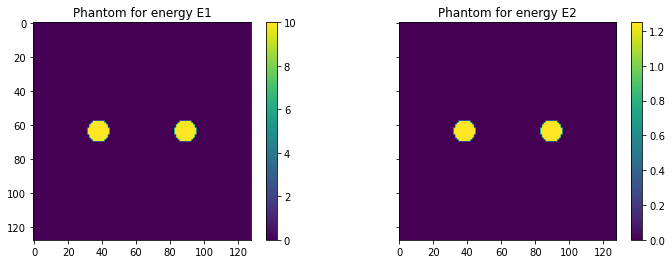

In [72]:
# build phantom

XX, YY = np.meshgrid(np.linspace(-1.0,1.0, 128), np.linspace(-1.0,1.0, 128))
RR = np.sqrt(XX**2 + YY**2)
RR[RR <= 1.0] = 0.0
RR[RR > 1.0] = 0.0
RR[np.sqrt(YY**2 + (XX-0.4)**2) < 0.1] = 10.0
RR[np.sqrt(YY**2 + (XX+0.4)**2) < 0.1] = 10.0

phantom_e1 = RR
phantom_e2 = phantom_e1 / 8

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
im1 = axs[0].imshow(phantom_e1)
fig.colorbar(im1, ax=axs[0])
axs[0].title.set_text('Phantom for energy E1')
im2 = axs[1].imshow(phantom_e2)
axs[1].title.set_text('Phantom for energy E2')
fig.colorbar(im2, ax=axs[1])
plt.show()


In [ ]:
# YOUR CODE HERE

**Réponse à l'exercice 2.5.:** VOTRE RÉPONSE

**Remarque:** sur l'image, si vous avez bien fait les choses, vous pouvez remarquer que l'artefact est particulièrement visible le long des [caustiques](https://fr.wikipedia.org/wiki/Caustique). Ce phénomène a été noté dans le livre de V. I. Arnold - Comprendre la nature mathématiquement, cependant, l'auteur du cours n'a pas encore réussi à expliquer ce phénomène (si vous souhaitez participer au développement du cours, vous pouvez vous pencher sur cette question et nous écrire par e-mail).

Le modèle mathématique ci-dessus pour l'émission polychromatique est utilisé dans les [algorithmes de correction](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=959297) de cet artefact.

## 3. Tomographies TEP / TEMP

Dans les exercices précédents, nous avons utilisé des données de rayonnement pour la transformation de Radon classique.
À partir des matériels de cours de physique, vous savez que dans le cas de TEP / TEMP, les données sont décrites par des transformations de Radon de rayonnement.

Dans les paragraphes suivants, vous êtes invité à implémenter un projecteur pour les transformations pondérées. Il est important de noter que 
dans le cas de poids non triviaux, la complexité de la tâche augmente considérablement et pour accélérer les calculs, il est nécessaire 
d'utiliser au maximum les "propriétés analytiques" des transformations. Par conséquent, avant de programmer les calculs des intégrales inférieures directement de manière frontale, réfléchissez à la façon dont vous pouvez implémenter efficacement la procédure avec le minimum d'opérations.

### 3.1. Tomographie par émission de positons - TEP

Comme nous l'avons vu dans les leçons précédentes, les données mesurées en tomographie par émission de positons sont également décrites par un processus de Poisson dont l'intensité est exprimée sous la forme d'une transformation de Radon pondérée de la fonction de densité de distribution de l'isotope :

\begin{align}
    &N(s,\theta) \sim \mathrm{Po}(t\cdot \Lambda_a(s,\theta)), \, (s,\theta)\in R\times S^1,\\
    &\Lambda_a(s,\theta) = R_{W_a}f(s,\theta) = \int\limits_{-\infty}^{+\infty} e^{-Pa(s,\theta)}
    f(s\theta + t\theta^\perp)\, dt, 
\end{align}

où $a=a(x)$ est la carte d'absorption, $f=f(x)$ est la densité (concentration) de l'isotope en un point $x\in R^2$.

**Exercice 3.1.** En utilisant les données (fantôme + carte d'absorption), modélisez les données de rayons $N(s,\theta)$ avec les paramètres $N_s = 256$, $N_\theta = 512$. Choisissez le paramètre $t$ de telle manière que le nombre maximal de photons le long des rayons soit égal à 500, c'est-à-dire $t_1 : t_1 \cdot \max |\Lambda_a(s,\theta)| = 500$ (bruit de Poisson faible) et $t_2 : t_2 \cdot \max |\Lambda_a(s,\theta)| = 50\sim 80$ (bruit de Poisson réaliste en PET / SPECT). La carte d'absorption dans le fichier joint est déjà normalisée, donc le rayon du support est $R = 1$.

**Indication**: essayez d'utiliser au minimum les boucles et utilisez les fonctions standard `radon2d(...)`.

In [ ]:
# plot attenuation map / leasure phantom (synthetic brain cancer case)

attenuation_map = np.reshape(np.fromfile('./att_map.bin', dtype=np.float), (512, 512))
pet_phantom = np.reshape(np.fromfile('./pet_phantom.bin', dtype=np.float), (512, 512))

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
im1 = axs[0].imshow(attenuation_map)
fig.colorbar(im1, ax=axs[0])
axs[0].title.set_text('Attenuation map')
im2 = axs[1].imshow(pet_phantom)
axs[1].title.set_text('PET phantom')
fig.colorbar(im2, ax=axs[1])
plt.show()

In [ ]:
# YOUR CODE HERE

**Exercice 3.2.** Restaurez les images des phantômes à partir des données de rayonnement $N(s,\theta)$ pour $t_1, t_2$, en utilisant l'algorithme FBP (utilisez soit votre propre code, soit la fonction `iradon` de la bibliothèque `scikit.image.transform`). Pour le lissage des images, vous pouvez utiliser les filtres de lissage du dernier exercice (par exemple, le filtre sinc). Expliquez comment et pourquoi les restaurations diffèrent pour différents $t$?

**Important :** Supposons que lors de la restauration, la carte d'absorption $a(x)$ vous est connue et que vous pouvez l'utiliser comme vous le souhaitez pour vos restaurations.

In [ ]:
# YOUR CODE HERE

**Réponse à l'exercice 3.2. :** VOTRE RÉPONSE ICI

### 3.2 Algorithme EM pour les tomographies émettrices PET/SPECT

L'algorithme EM pour PET et SPECT a été proposé initialement dans [l'article Shepp & Vardi, 1982](https://ieeexplore.ieee.org/abstract/document/4307558). L'idée principale est d'utiliser un schéma de complétion des données (data-augmentation scheme) de la forme suivante :

\begin{align}
    &Y_i^t \sim \mathrm{Po}(t\cdot \Lambda_{a}(s_i,\theta_i)), \, i\in \{1, \dots, d\} \text{ - données connues (sinogramme)}, \, \Lambda_{a,i} = \Lambda_a(s_i, \theta_i) = \sum_{j=1}^{p}A_{ij}f_j,\\
    &N^t_{ij} \sim \mathrm{Po}(t\cdot A_{ij}f_j), \, i\in \{1, \dots, d\}, \, j\in \{1, \dots, p\} \text{ - variables latentes (latent-variables)}, \\
    &N^t_{ij} \text{ - nombre de photons enregistrés le long de la ligne $i$, qui ont été créés dans le pixel $j$}\\
    &(N^t, Y^t) \text{ - données complétées (data augmentation scheme)}, \, \sum_{j=1}^{p}N_{ij}^t = Y_i^t,
\end{align}
où $A = (A_{ij})$ est la matrice de transformation pondérée de Radon pour PET (voir la formule ci-dessus).

Les fonctions de vraisemblance $L(Y^t | f, t)$ et $L(Y^t, N^t | f, t)$ sont données par les formules suivantes :

\begin{align}
    L(Y^t | f, t) &= \sum\limits_{i=1}^{d}Y_i^t \log(t\cdot \Lambda_{a,i}) - t \cdot \Lambda_{a,i}, \, 
    \Lambda_{a,i} = \Lambda_a(s_i, \theta_i) = \sum_{j=1}^{p}A_{ij}f_j,\\
    L(Y^t, N^t | f, t) &= \sum\limits_{i=1}^{d}\sum\limits_{j=1}^{p}N_{ij}^t\log(t \cdot A_{ij}) - t \cdot A_{ij}, \, \sum_{j=1}^{p}N_{ij}^t = Y_i^t.
\end{align}

En utilisant les variables auxiliaires $N_{ij}^t$ et les formules ci-dessus, on peut obtenir une formule explicite pour le terme $\varphi(\theta, \theta^{(n)})$, et par conséquent dériver l'algorithme EM pour les tomographies émettrices PET / SPECT :

\begin{align}
    f^{(n+1)}_j = \dfrac{1}{tA_j} \sum\limits_{i=1}^{d} \dfrac{Y_i^t A_{ij}f_{j}^{(n)}}{\Lambda_{a,i}^{(n)}}, \, A_j = \sum\limits_{i=1}^{d} A_{ij}, \, A_j \neq 0, \,  \Lambda_{a,i} = \sum\limits_{j=1}^{p} A_{ij}f_j.
\end{align}

**Exercice :** Obtenez la formule de l'algorithme EM ci-dessus. *Indication :* En un point de maximum, la condition d'optimalité $\nabla L(Y^t | f, t) = 0$ n'est généralement pas vérifiée en raison de la contrainte non différentiable $f \in R^p_+$. Dans ce cas, il faut utiliser la condition d'optimalité KKT (Karush-Kuhn-Tucker).

**Exercice 3.3.** Implémentez l'algorithme EM selon la formule ci-dessus, en utilisant uniquement les transformations de Radon directes et duales, et appliquez-le aux données de l'Exercice 3.2. (a) Obtenez des reconstructions après 10, 100, 500 itérations de l'algorithme et suivez comment la bruitance de l'image change (augmente, diminue et essayez d'expliquer pourquoi). 
(b) Appliquez un filtre aux images reconstruites (voir Exercice 3.2) et comparez les reconstructions avec celles obtenues par FBP en utilisant le filtre. Où la qualité des reconstructions est-elle meilleure ? Expliquez pourquoi.

In [66]:
# YOUR CODE HERE

**Réponse à l'exercice 3.3. :** VOTRE RÉPONSE ICI

### 3.3. Tomographie par émission mono-photone - SPECT*

Dans le cas de la SPECT, les données mesurées sont décrites par le modèle suivant (voir le cours de physique) :

\begin{align}
    &N(s,\theta) \sim \mathrm{Po}(t\cdot \Lambda_a(s,\theta)), \, (s,\theta)\in R\times S^1,\\
    &\Lambda_a(s,\theta) = R_{W_a}f(s,\theta) = \int\limits_{-\infty}^{+\infty} e^{-Da(s\theta + t\theta^\perp,\theta)}
    f(s\theta + t\theta^\perp)\, dt, \\
    &Da(x,\theta) = \int\limits_{0}^{+\infty}a(x + t\theta^\perp)\, dt, \, x\in R^2, \theta\in S^1.
\end{align}

Dans ce cas, pour modéliser les données de rayonnement $N(s, \theta)$, il n'est pas suffisant d'utiliser uniquement la fonction `radon2d(...)` en raison du poids $W = e^{-Da}$, qui ne peut pas être sorti du signe intégral comme c'était le cas pour la PET. Le calcul direct de l'intégrale $R_{W_a}$ semble extrêmement coûteux en ressources - à chaque point d'intégration le long du rayon, il faut calculer l'intégrale $e^{-Da}$ et finalement le nombre d'opérations pour un seul rayon est de l'ordre de $O(N_p^2)$, où $N_p$ est le nombre de pixels dans l'image.

Cependant, dans ce cas, on peut proposer une relaxation des calculs des intégrales exactes en utilisant l'*équation de transport pour la tomographie émissive* :

\begin{align}
    &\psi_a(x,\theta)  \text{ - intensité du flux de photons le long du rayon } \gamma(x,\theta) = \{y = x + t\theta, \, x\in R^2, \theta\in S^1, t\in R\}, \\
    &  (\theta\cdot\nabla) \psi_a(x,\theta) + a(x) \psi_a(x,\theta) = f(x), \, (\theta\cdot \nabla) \text{ - dérivée dans la direction } \theta, \text{ c'est-à-dire le long du rayon }\gamma(x,\theta), \\
    & \lim_{t\rightarrow -\infty} \psi_a(s\theta + t\theta^\perp, \theta^\perp) = 0, \, \lim_{t\rightarrow +\infty}\psi_a(s\theta+t\theta^\perp, \theta^\perp) = R_{W_a}f(s,\theta) \text{ (voir la formule ci-dessus)}.
\end{align}

En utilisant la formule ci-dessus, on peut écrire, par exemple, un schéma d'Euler explicite (bien que pas tout à fait stable) pour trouver $R_{W_a}(s,\theta)$ en $O(N_p)$ :

\begin{align}
    \dfrac{\psi_a^{k+1}-\psi_a^k}{\Delta} = -a^k\psi^k_a + f^k, \, \psi_a^k = 0, \, \psi_a^{\infty} = R_{W_a}(s_i,\theta_i),
\end{align}
où l'indice $k$ désigne l'indice du $k$-ième point sur le rayon orienté $(s_i,\theta_i)$, $\Delta > 0$ est le pas le long du rayon (on peut choisir un ordre de grandeur de la moitié de la longueur du pas de discrétisation).

**Exercice 3.4.** Implémentez le projecteur `radon2d_spect(...)` en utilisant l'équation de transport pour la tomographie émissive et générer les données $N(s,\theta)$ en utilisant les mêmes données d'entrée et paramètres que dans l'exercice 3.1. Tracez les sinogrammes obtenus.

In [ ]:
# YOUR CODE HERE

**Exercice 3.5.** L'algorithme EM pour SPECT est identique à l'algorithme pour PET, seules les matrices des transformations directes diffèrent. Effectuez l'Exercice 3.3 sur les données SPECT que vous avez générées dans l'exercice 3.4.

In [ ]:
# YOUR CODE HERE

**Réponse à l'exercice 3.5.:** VOTRE RÉPONSE ICI

## 4. Microtomographie (MicroCT)

La microtomographie par rayons X (X-ray microtomography, MicroCT) est un autre domaine de la tomographie par rayons X qui se consacre à la reconstruction d'images de la structure d'objets petits (jusqu'à quelques millimètres de diamètre).


<table>
<tr>
 <td> <img src="./microct-1.png" alt="micro-ct-1" style="width: 400px;"/> </td>
 <td> <img src="./microct-2.jpg" alt="micro-ct-2" style="width: 300px;"/> </td>
</tr>
<tr>
    <td> image d'une radiolarie obtenue par MicroCT</td>
    <td> section d'un os tibia de souris</td>
</tr>
</table>



Selon le modèle physique et l'utilisation des transformations de Radon, la microtomographie ne diffère pas de la tomographie par rayons X standard. Cependant, il existe quelques différences pratiques importantes :

  * en général - les cibles sont non vivantes (à moins qu'il ne s'agisse d'animaux très petits), ce qui signifie qu'il n'y a pas de limitations sur la dose de rayonnement, et donc pas de problèmes de bruit statistique ;
  * le faisceau de photons X est obtenu à l'aide d'un synchrotron qui permet de garantir une divergence extrêmement faible du faisceau et même la cohérence optique des photons (conservation de la phase) ;
  * l'émetteur et le détecteur ne tournent pas autour de l'objet, mais l'objet est fixé sur un support et tourne autour de son axe ; grâce à cela, il n'y a pas de limitation sur le pas de discrétisation dans les données rayonnantes.
  
Vous êtes invité à effectuer une reconstruction dans le cadre d'une microtomographie où l'objet irradié est une dent humaine.

**Exercice 4.1** En raison de cette résolution si fine, il se pose le problème suivant : le centre de rotation de l'objet n'est en réalité pas connu et l'établir avec une précision inférieure à la résolution est techniquement très difficile. Ainsi, les données rayonnantes dans le cas bidimensionnel sont données par la fonction 
\begin{equation}
F(s,\theta) = g(s-s_0, \theta), \, g(s,\theta) = Rf(s,\theta), \, s, \, \theta\in S^1
\end{equation}

où $s_0$ est un décalage inconnu, $R$ est la transformation de Radon sur le plan, et $f$ est la fonction à reconstruire. Le code ci-dessous charge les données rayonnantes et les convertit en format `numpy.ndarray`. Votre tâche consiste à reconstruire l'image de la dent à partir de ces données rayonnantes - elle doit montrer la structure interne de la dent et d'autres détails fins.

In [ ]:
# download h5 data with counts data

fname = 'tooth.h5'
data_status = os.path.exists('./' + fname)

if data_status == "False":
    url = 'https://raw.github.com/fedor-goncharov/pdo-tomography-course/master/seminar-materials/seminar-3/tooth.h5'
    output_path = './'
    wget.download(url, output_path)
    

# 1. preprocess data 
proj, flat, dark, theta = dxchange.read_aps_32id(
    fname = fname,
    sino = (0,2),
    )

# 1.1 normalize projection data and take -log
proj = tp.normalize(proj, flat, dark)
proj = tp.minus_log(proj)

# 1.2 convert to numpy.ndarray of size 181 x 640
proj = np.reshape(proj[:, 0, :], (181, 640))

# 1.3 (optional) plot image of raw data
plt.imshow(proj)
plt.title('MicroCT raw data')
plt.show()


In [69]:
# YOUR CODE HERE